# Analyze Picard Method

This notebooks produces Picard solver analysis of Figure 12 in the paper.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [ ]:
import superape
import apebench
import exponax as ex

In [3]:
import superape._parser


p_iter = superape._parser.parse_simulator(
    "fd;1.0;100",
    num_points=60,
    linear_difficulties=(0.0, 0.0, 0.2, 0.0, 0.0),
    convection_difficulty=-8.0,
)
p_1 = superape._parser.parse_simulator(
    "fd;1.0;1",
    num_points=60,
    linear_difficulties=(0.0, 0.0, 0.2, 0.0, 0.0),
    convection_difficulty=-8.0,
)

In [4]:
ic_dist = apebench.components.ic_dict["fourier"](
    "fourier;1;False;True",
    1,
)

In [5]:
train_ic_set = ex.build_ic_set(
    ic_dist,
    num_points=60,
    num_samples=300,
    key=jax.random.key(100),
)

In [6]:
trj_p_iter = jax.vmap(ex.rollout(p_iter, 100, include_init=True))(train_ic_set)
trj_p_1 = jax.vmap(ex.rollout(p_1, 100, include_init=True))(train_ic_set)

In [7]:
trj_p_1__one_step = jax.vmap(jax.vmap(p_1))(trj_p_iter[:, :-1])

In [8]:
trj_p_iter.shape

(300, 101, 1, 60)

In [9]:
diagnosing = jax.vmap(
    jax.vmap(
        p_iter.diagnose_picard
    )
)(trj_p_iter)

In [10]:
diagnosing.shape

(300, 101)

In [11]:
diagnosing = jnp.array(diagnosing)

In [12]:
diagnosing_median = jnp.median(diagnosing, axis=0)
diagnosing_25 = jnp.percentile(diagnosing, 25, axis=0)
diagnosing_75 = jnp.percentile(diagnosing, 75, axis=0)

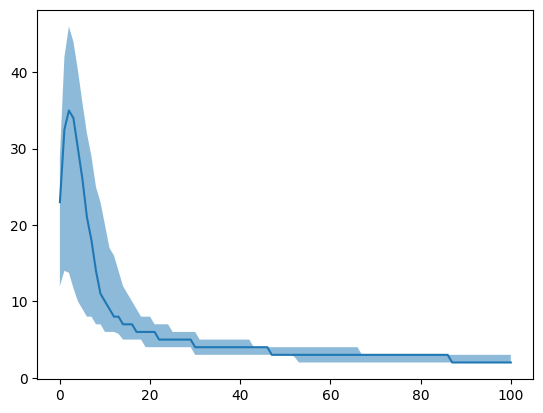

In [13]:
plt.plot(diagnosing_median)
plt.fill_between(range(diagnosing_median.shape[0]), diagnosing_25, diagnosing_75, alpha=0.5)

In [14]:
one_step_error = jnp.linalg.norm(trj_p_1__one_step - trj_p_iter[:, 1:], axis=(-1, -2))
one_step_error_relative = one_step_error / jnp.linalg.norm(trj_p_iter[:, 1:], axis=(-1, -2))


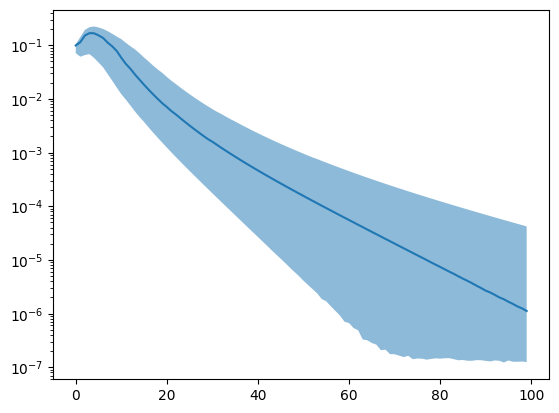

In [15]:
one_step_error_relative_median = jnp.median(one_step_error_relative, axis=0)
one_step_error_relative_25 = jnp.percentile(one_step_error_relative, 25, axis=0)
one_step_error_relative_75 = jnp.percentile(one_step_error_relative, 75, axis=0)
plt.semilogy(one_step_error_relative_median)
plt.fill_between(range(one_step_error_relative_median.shape[0]), one_step_error_relative_25, one_step_error_relative_75, alpha=0.5)


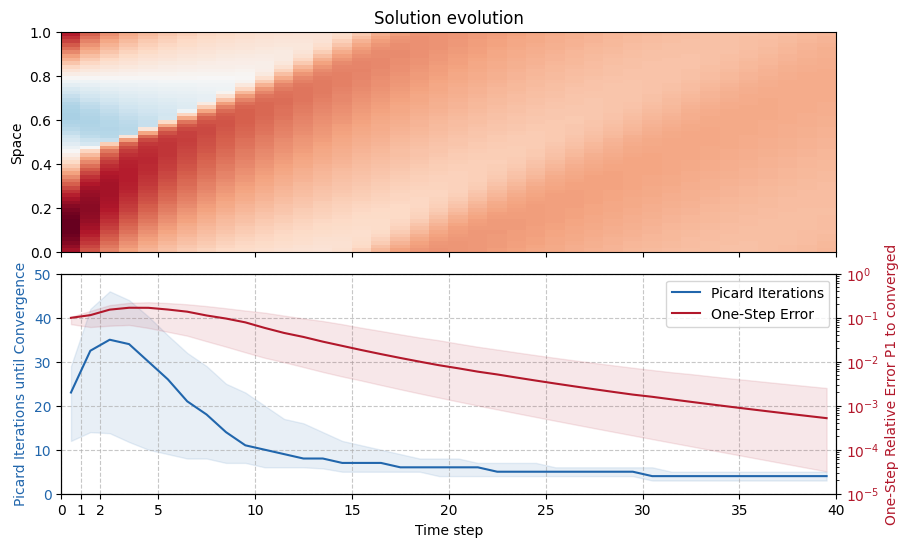

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].imshow(trj_p_iter[0, :40, 0, :].T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, origin="lower", extent=[0, 40, 0, 1])
# Add title to the first subplot
axs[0].set_title('Solution evolution')
axs[0].set_ylabel('Space')

# Create the second subplot with shaded areas for percentiles
plot_iters = axs[1].plot(jnp.arange(1, 40+1)-0.5, diagnosing_median[:40], color="#2166ac")
axs[1].fill_between(jnp.arange(1, 40+1)-0.5, diagnosing_25[:40], diagnosing_75[:40], alpha=0.1, color='#2166ac', label='25-75 percentile')
axs[1].set_ylim(0, 50)
# Create a second y-axis for the one-step error
ax2 = axs[1].twinx()
plot_error = ax2.semilogy(jnp.arange(1, 40+1)-0.5, one_step_error_relative_median[:40], label='One-step error', color="#b2182b")
ax2.fill_between(jnp.arange(1, 40+1)-0.5, one_step_error_relative_25[:40], one_step_error_relative_75[:40], alpha=0.1, color='#b2182b', label='25-75 percentile')
ax2.set_ylabel('One-Step Relative Error P1 to converged', color='#b2182b')
ax2.tick_params(axis='y', labelcolor='#b2182b')
ax2.set_ylim(1e-5, 1e0)

# Add a legend to distinguish between the two plots
axs[1].set_ylabel('Picard Iterations until Convergence', color='#2166ac')
axs[1].tick_params(axis='y', labelcolor='#2166ac')
axs[1].set_xticks([0, 1, 2, 5, 10, 15, 20, 25, 30, 35, 40])

# Set common x-axis label
axs[1].set_xlabel('Time step')
# Create a joint legend for both plots
axs[1].legend(plot_iters + plot_error, ['Picard Iterations', 'One-Step Error'], loc='upper right')

# Remove the individual legends
if ax2.get_legend():
    ax2.get_legend().remove()

# Add grid to the second subplot
axs[1].grid(True, linestyle='--', alpha=0.7)

# Adjust the spacing between subplots
plt.subplots_adjust(hspace=0.1)  # Increase vertical space between subplots

fig.savefig("picard_analysis.pdf", bbox_inches="tight")